In [1]:
import matplotlib.pyplot as plt

import openmdao.api as om

import dymos as dm
from dymos.examples.plotting import plot_results
from min_time_climb_ode import MinTimeClimbODE
import pandas as pd

In [2]:
p = om.Problem(model=om.Group())

p.driver = om.ScipyOptimizeDriver()
p.driver.options['optimizer'] = 'SLSQP'
p.driver.declare_coloring()
p.driver.options['disp'] = False
# p.driver.opt_settings['maxtime'] = 10  # seconds
# p.driver.opt_settings['iters'] = 3
p.driver.options['maxiter'] = 10
p.driver.options['tol'] = 1.0e-5


#
# Instantiate the trajectory and phase
#
traj = dm.Trajectory()

phase = dm.Phase(ode_class=MinTimeClimbODE,
                 transcription=dm.Radau(num_segments=15, order=3,compressed=False))

traj.add_phase('phase0', phase)

In [3]:
p.model.add_subsystem('traj', traj)

#
# Set the options on the optimization variables
# Note the use of explicit state units here since much of the ODE uses imperial units
# and we prefer to solve this problem using metric units.
#
phase.set_time_options(fix_initial=True, duration_bounds=(50, 400),
                       duration_ref=100.0)

phase.add_state('r', fix_initial=True, lower=0, upper=1.0E6, units='m',
                ref=1.0E3, defect_ref=1.0E3,
                rate_source='flight_dynamics.r_dot')

phase.add_state('h', fix_initial=True, lower=0, upper=20000.0, units='m',
                ref=1.0E2, defect_ref=1.0E2,
                rate_source='flight_dynamics.h_dot')

phase.add_state('v', fix_initial=True, lower=10.0, units='m/s',
                ref=1.0E2, defect_ref=1.0E2,
                rate_source='flight_dynamics.v_dot')

phase.add_state('gam', fix_initial=True, lower=-1.5, upper=1.5, units='rad',
                ref=1.0, defect_ref=1.0,
                rate_source='flight_dynamics.gam_dot')

phase.add_state('m', fix_initial=True, lower=10.0, upper=1.0E5, units='kg',
                ref=1.0E3, defect_ref=1.0E3,
                rate_source='prop.m_dot')

phase.add_control('alpha', units='deg', lower=-8.0, upper=8.0, scaler=1.0,
                  rate_continuity=True, rate_continuity_scaler=100.0,
                  rate2_continuity=False)

phase.add_parameter('S', val=49.2386, units='m**2', opt=False, targets=['S'])
phase.add_parameter('Isp', val=1600.0, units='s', opt=False, targets=['Isp'])
phase.add_parameter('throttle', val=1.0, opt=False, targets=['throttle'])

#
# Setup the boundary and path constraints
#
phase.add_boundary_constraint('h', loc='final', equals=20000, scaler=1.0E-3)
phase.add_boundary_constraint('aero.mach', loc='final', equals=1.0)
phase.add_boundary_constraint('gam', loc='final', equals=0.0)

phase.add_path_constraint(name='h', lower=100.0, upper=20000, ref=20000)
phase.add_path_constraint(name='aero.mach', lower=0.1, upper=1.8)

# Minimize time at the end of the phase
phase.add_objective('time', loc='final', ref=1.0)

p.model.linear_solver = om.DirectSolver()

#
# Setup the problem and set the initial guess
#
p.setup(check=True)

phase.set_time_val(initial=0.0, duration=350)
phase.set_state_val('r', [0.0, 50000.0])
phase.set_state_val('h', [100.0, 20000.0])
phase.set_state_val('v', [135.964, 283.159])
phase.set_state_val('gam', [0.0, 0.0])
phase.set_state_val('m', [19030.468, 10000.])
phase.set_control_val('alpha', [2.0, 5.0])

#
# Solve for the optimal trajectory
#
sol=p.run_driver()
sim=traj.simulate()


--- Constraint Report [traj] ---
    --- phase0 ---
        [final]   2.0000e+04 == h [m]
        [final]   1.0000e+00 == aero.mach [None]
        [final]   0.0000e+00 == gam [rad]
        [path]    1.0000e+02 <= h <= 2.0000e+04  [m]
        [path]    1.0000e-01 <= aero.mach <= 1.8000e+00  [None]

INFO: checking out_of_order...
INFO:     out_of_order check complete (0.001779 sec).
INFO: checking system...
INFO:     system check complete (0.000040 sec).
INFO: checking solvers...
INFO:     solvers check complete (0.000474 sec).
INFO: checking dup_inputs...
INFO:     dup_inputs check complete (0.000122 sec).
INFO: checking missing_recorders...
INFO:     missing_recorders check complete (0.001436 sec).
INFO: checking unserializable_options...
INFO:     unserializable_options check complete (0.003678 sec).
INFO: checking comp_has_no_outputs...
INFO:     comp_has_no_outputs check complete (0.000124 sec).
INFO: checking auto_ivc_warnings...
INFO:     auto_ivc_warnings check complete (0.00001

c:\Users\savar\anaconda3\Lib\site-packages\openmdao\core\total_jac.py:1728: DerivativesWarning:Constraints or objectives [('traj.phases.phase0->path_constraint->h', inds=[(0, 0)]), ('traj.phases.phase0->path_constraint->mach', inds=[(0, 0)])] cannot be impacted by the design variables of the problem.


Optimization FAILED.
Iteration limit reached
-----------------------------------


c:\Users\savar\anaconda3\Lib\site-packages\openmdao\core\group.py:1166: DerivativesWarning:Constraints or objectives [ode_eval.control_interp.control_rates:alpha_rate, ode_eval.control_interp.control_rates:alpha_rate2, ode_eval.control_interp.control_values:alpha] cannot be impacted by the design variables of the problem because no partials were defined for them in their parent component(s).



Simulating trajectory traj
Done simulating trajectory traj


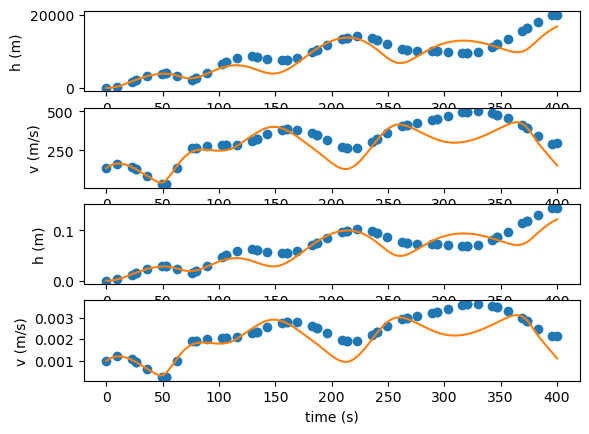

In [4]:
from sklearn.preprocessing import normalize
import numpy as np
%matplotlib inline
x = p.get_val('traj.phase0.timeseries.h')
y = p.get_val('traj.phase0.timeseries.v')
t = p.get_val('traj.phase0.timeseries.time')


x_exp = sim.get_val('traj.phase0.timeseries.h')
y_exp = sim.get_val('traj.phase0.timeseries.v')
t_exp = sim.get_val('traj.phase0.timeseries.time')



combined = np.concatenate([x.flatten(), y.flatten(), x_exp.flatten(), y_exp.flatten()]).reshape(1, -1)

# Normalize the combined vector
combined_n = normalize(combined, norm='l2', axis=1)

# Reshape back into original shapes
split_indices = [x.size, y.size, x_exp.size]  # Indices to split at
x_n, y_n, x_exp_n, y_exp_n = np.split(combined_n.flatten(), np.cumsum(split_indices))

# Reshape back to original shapes
x_n = x_n.reshape(x.shape)
y_n = y_n.reshape(y.shape)
x_exp_n = x_exp_n.reshape(x_exp.shape)
y_exp_n = y_exp_n.reshape(y_exp.shape)

fig, axes = plt.subplots(nrows=4, ncols=1)

axes[0].plot(t, x, 'o')
axes[0].plot(t_exp, x_exp, '-')
axes[0].set_ylabel('h (m)')
axes[0].set_xlabel('time (s)')

axes[1].plot(t, y, 'o')
axes[1].plot(t_exp, y_exp, '-')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('v (m/s)')

axes[2].plot(t, x_n, 'o')
axes[2].plot(t_exp, x_exp_n, '-')
axes[2].set_ylabel('h (m)')
axes[2].set_xlabel('time (s)')

axes[3].plot(t, y_n, 'o')
axes[3].plot(t_exp, y_exp_n, '-')
axes[3].set_xlabel('time (s)')
axes[3].set_ylabel('v (m/s)')

plot_filename = "trajectory_plot.png"
plt.savefig(plot_filename, dpi=300)
plt.show()

data_case_number = 1  # Change this as needed
csv_filename = f"data_case_{data_case_number}.csv"

data = pd.DataFrame({
    "time": t.flatten(),
    "h": x.flatten(),
    "v": y.flatten()
})

data.to_csv(csv_filename, index=False)


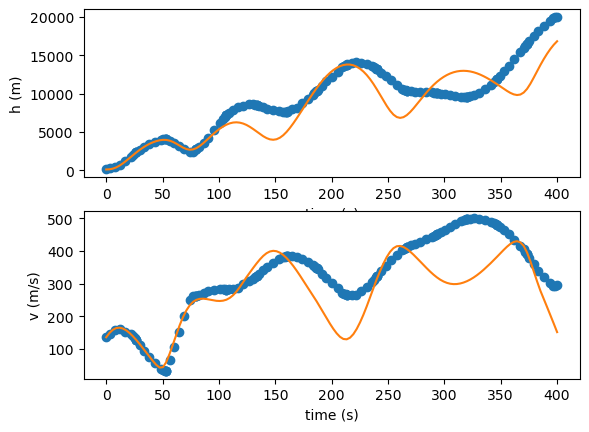

           time             h           v         h_sim       v_sim
0      0.000000    100.000000  135.964000    100.000000  135.964000
1      3.749085    234.514909  147.214349    124.592954  149.391762
2      7.498169    369.029818  158.464698    211.559974  158.902132
3     11.922997    688.606251  160.894028    372.322281  164.170479
4     17.095969   1213.072227  153.557232    605.830482  165.306836
..          ...           ...         ...           ...         ...
145  388.237365  18813.357813  321.016040  14479.336993  253.112694
146  393.410336  19486.130645  302.345190  15180.190941  228.454282
147  396.725544  19845.897280  293.814719  15807.685235  203.424635
148  398.362772  19922.948640  294.443299  16353.724784  177.752198
149  400.000000  20000.000000  295.071880  16808.052496  151.709348

[150 rows x 5 columns]


In [ ]:
%matplotlib inline
from scipy.interpolate import interp1d
import numpy as np
def interpolate_arrays(x: np.ndarray, x_exp: np.ndarray):
    target_length = max(len(x.flatten()), len(x_exp.flatten()))
    
    x_indices = np.linspace(0, 1, len(x.flatten()))
    x_exp_indices = np.linspace(0, 1, len(x_exp.flatten()))
    
    interpolator_x = interp1d(x_indices, x.flatten(), kind='linear', fill_value='extrapolate')
    interpolator_x_exp = interp1d(x_exp_indices, x_exp.flatten(), kind='linear', fill_value='extrapolate')
    
    new_indices = np.linspace(0, 1, target_length)
    x_resampled = interpolator_x(new_indices)
    x_exp_resampled = interpolator_x_exp(new_indices)
    
    return x_resampled, x_exp_resampled


x_n,x_exp_n=interpolate_arrays(x_n,x_exp_n)
y_n,y_exp_n=interpolate_arrays(y_n,y_exp_n)
t,t_exp=interpolate_arrays(t,t_exp)

fig, axes = plt.subplots(nrows=2, ncols=1)

axes[0].plot(t, x_n, 'o')
axes[0].plot(t_exp, x_exp_n, '-')
axes[0].set_ylabel('h (m)')
axes[0].set_xlabel('time (s)')

axes[1].plot(t, y, 'o')
axes[1].plot(t_exp, y_exp, '-')
axes[1].set_xlabel('time (s)')
axes[1].set_ylabel('v (m/s)')
plt.show()

data = pd.DataFrame({
    "time": t.flatten(),
    "h": x.flatten(),
    "v": y.flatten(),
    "h_sim": x_exp.flatten(),
    "v_sim": y_exp.flatten()

})

print(data)

c:\Users\savar\anaconda3\Lib\site-packages\dymos\examples\plotting.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig.legend(loc='lower center', ncol=2)


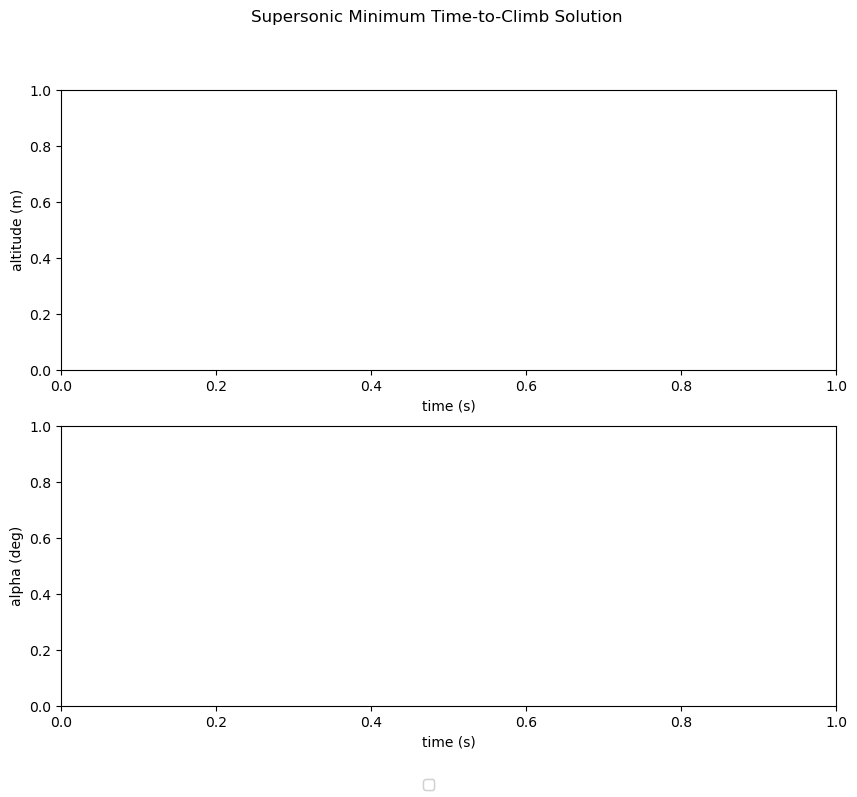

In [46]:
%matplotlib inline
# sol = om.CaseReader(p.get_outputs_dir() / 'dymos_solution.db').get_case('final')
# sim = om.CaseReader(traj.sim_prob.get_outputs_dir() / 'dymos_simulation.db').get_case('final')

plot_results([('traj.phase0.timeseries.time', 'traj.phase0.timeseries.h',
               'time (s)', 'altitude (m)'),
              ('traj.phase0.timeseries.time', 'traj.phase0.timeseries.alpha',
               'time (s)', 'alpha (deg)')],
             title='Supersonic Minimum Time-to-Climb Solution',
             p_sol=sol, p_sim=sim)

plt.show()